In [8]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 67.7 MB/s eta 0:00:00:00:0100:01

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [10]:
results_ = pd.read_csv('~/ising_EnergyOverTime/min_max_results_additions_fireGradient.csv')
results_.columns

Index(['Unnamed: 0', 'mouse_id', 'stim', 'max_velocity', 'min_velocity',
       'max_velocity_idx', 'min_velocity_idx', 'max_acceleration',
       'min_acceleration', 'max_acceleration_idx', 'min_acceleration_idx',
       'max_energy', 'min_energy', 'max_energy_idx', 'min_energy_idx',
       'max_firing_rate', 'min_firing_rate', 'max_firing_idx',
       'min_firing_idx', 'firing_rate_gradient_velocity_max',
       'firing_rate_gradient_velocity_min', 'file_name', 'reach_id',
       'num_neurons', 'exlcuded_reach', 'fChR2', 'fChR5', 'fChR4', 'cChR1',
       'DJC002', 'DJC000', 'mouse_id_normalized'],
      dtype='object')

In [5]:
# Hypothesis, does peak / bottom of energy align with max velocity better then firing rate
# null hypothesis - Energy does not align with max velocity better then firing rate

# variables 
# - max velocity idx -- max_v_i
# - max energy idx -- max_e_i
# - min energy idx -- min_e_i
# - max firing rate idx -- max_fr_i 
# - min firing rate idx -- min_fr_i
# - difference in rest firing rate to firing rate at idx max velocity -- delta_fr

# probability test including gradient of fr around max velocity
# P(abs(max_v_i - max_e_i) < abs(max_v_i - min_fr_i)) given delta_fr < 0
# P(abs(max_v_i - min_e_i) < abs(max_v_i - max_fr_i)) given delta_fr >= 0

# idependent probabilities
# 1: P(abs(max_v_i - max_e_i) < abs(max_v_i - min_fr_i))
# 2: P(abs(max_v_i - min_e_i) < abs(max_v_i - max_fr_i))

# Test the probability of the event energy peaks around max velocity when firing rate dips, 
# or energy drops around firing rate goes up


# Hypothesis, energy peaks or bottoms out around the max velocity better then firing rate. 
# 

In [34]:
from scipy import stats

In [12]:
max_v_i = results_['max_velocity_idx']
max_e_i = results_['max_energy_idx']
min_e_i = results_['min_energy_idx']
max_fr_i = results_['max_firing_idx']
min_fr_i = results_['min_firing_idx']
delta_fr = results_['firing_rate_gradient_velocity_max']

In [22]:
statistic, p_value = stats.shapiro(abs(max_v_i - max_e_i))
p_value

np.float64(1.6511704274852204e-17)

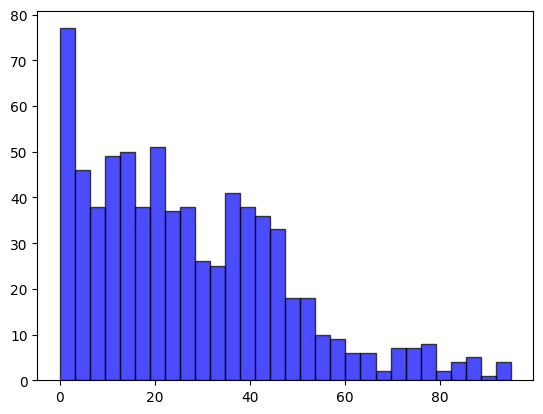

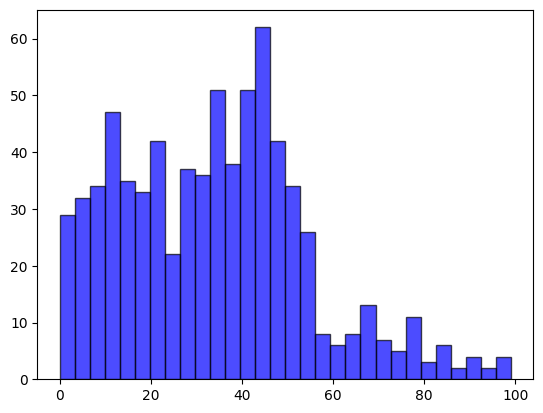

In [24]:
import matplotlib.pyplot as plt
plt.hist(abs(max_v_i - max_e_i), bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.show()

plt.hist(abs(max_v_i - max_fr_i), bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.show()


In [31]:
import numpy as np
max_v_i.shape

(730,)

# Test if max energy is closer to max velocity then max firing rate

In [48]:
from scipy.stats import binomtest

# Count events where energy distance > firing rate distance
# i.e., firing rate is CLOSER to velocity than energy is
eDelta_greater_frDelta = np.where(abs(max_v_i - max_e_i) > abs(max_v_i - max_fr_i))[0].shape[0]
total_events = max_v_i.shape[0]

# One-sided binomial test
p_value_one = binomtest(eDelta_greater_frDelta, total_events, p=0.5, alternative='greater')

# HYPOTHESES:
# H0: P(firing rate closer to velocity) ≤ 0.5 
#     (firing rate is not closer more than half the time)
# H1: P(firing rate closer to velocity) > 0.5 
#     (firing rate is closer more than half the time)

# INTERPRETATION:
# - Small p-value (< 0.05): Reject H0 → firing rate is closer more often
# - Large p-value (≥ 0.05): Fail to reject H0 → no evidence firing rate is closer more often

# WHAT WE'RE TESTING:
# Does firing rate tend to be closer to velocity than energy is?
P_v = p_value_one.pvalue
print(f"P Value: {P_v}, num_events(energy closer then Fr): {total_events- eDelta_greater_frDelta}/{total_events}")
if P_v < 0.05:
    print(f"reject the null hypothesis - Firing rate is closer more often") 
if P_v >= 0.05:
    print(f"Fail to reject H0 - no evidence firing rate is closer more often") 

P Value: 0.9999999999950738, num_events(energy closer then Fr): 456/730
Fail to reject H0 - no evidence firing rate is closer more often


# Find best descriminator of Max velocity
Test if deciding between using max energy or min energy when firing goes up and down

In [49]:
fr_delta_increase = results_[delta_fr > 0]
fr_delta_increase.columns

Index(['Unnamed: 0', 'mouse_id', 'stim', 'max_velocity', 'min_velocity',
       'max_velocity_idx', 'min_velocity_idx', 'max_acceleration',
       'min_acceleration', 'max_acceleration_idx', 'min_acceleration_idx',
       'max_energy', 'min_energy', 'max_energy_idx', 'min_energy_idx',
       'max_firing_rate', 'min_firing_rate', 'max_firing_idx',
       'min_firing_idx', 'firing_rate_gradient_velocity_max',
       'firing_rate_gradient_velocity_min', 'file_name', 'reach_id',
       'num_neurons', 'exlcuded_reach', 'fChR2', 'fChR5', 'fChR4', 'cChR1',
       'DJC002', 'DJC000', 'mouse_id_normalized'],
      dtype='object')

In [54]:
from scipy.stats import binomtest

# We now see from the last cell that max energy is by far close to max velocity then max firing rate.
# In this we now test the hypothesis if if energy min/max based on firing rate gradient shows a better signal


# Count events
# if gradient decrease, min energy further from max firing rate
fr_gradient_increase = results_[delta_fr > 0]
gradient_increase_minEnergyIdx_further = np.where(
                                                abs(fr_gradient_increase['max_velocity_idx'] - fr_gradient_increase['min_energy_idx']) > 
                                                abs(fr_gradient_increase['max_velocity_idx'] - fr_gradient_increase['max_firing_idx']) )[0].shape[0]

# if gradient decrease, max energy further from min firing rate
fr_gradient_decrease = results_[delta_fr < 0]
gradient_increase_minEnergyIdx_further = np.where(
                                                abs(fr_gradient_decrease['max_velocity_idx'] - fr_gradient_decrease['max_energy_idx']) > 
                                                abs(fr_gradient_decrease['max_velocity_idx'] - fr_gradient_decrease['min_firing_idx']) )[0].shape[0]

sum_events = gradient_increase_minEnergyIdx_further + gradient_increase_minEnergyIdx_further
n = fr_gradient_increase.shape[0] + fr_gradient_decrease.shape[0]

# One-sided binomial test
p_value_one = binomtest(sum_events, total_events, p=0.5, alternative='greater')

# HYPOTHESES:
# H0: P(firing rate closer to velocity) ≤ 0.5 
#     (firing rate is not closer more than half the time)
# H1: P(firing rate closer to velocity) > 0.5 
#     (firing rate is closer more than half the time)

# INTERPRETATION:
# - Small p-value (< 0.05): Reject H0 → firing rate is closer more often
# - Large p-value (≥ 0.05): Fail to reject H0 → no evidence firing rate is closer more often

# WHAT WE'RE TESTING:
# Does firing rate tend to be closer to velocity than energy is?
P_v = p_value_one.pvalue
print(f"P Value: {P_v}, num_events(energy closer then Fr): {n- sum_events}/{n}")
if P_v < 0.05:
    print(f"reject the null hypothesis - Firing rate is closer more often") 
if P_v >= 0.05:
    print(f"Fail to reject H0 - no evidence firing rate is closer more often")

P Value: 1.0, num_events(energy closer then Fr): 488/730
Fail to reject H0 - no evidence firing rate is closer more often
